# SIMPLE K-MEANS IMPLEMENTATION FROM SCRATCH


In [ ]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs


# 1. CREATE SIMPLE DATASET

Prompt:
Generate code to simulate a synthetic dataset for a clustering task. The implementation must follow these requirements:

1. Generate a dataset with exactly 15 samples. It should be distributed across 3 distinct cluster centers.
2. Standard deviation of the clusters should be 1.0.
3. Fix the random seed to ensure the dataset is reproducible.
4. Store the generated data points in a variable named 'X' and their true cluster labels in a variable named 'y'.
5. Plot the points

Write this cleanly using python and numpy or any package that is available in data science.





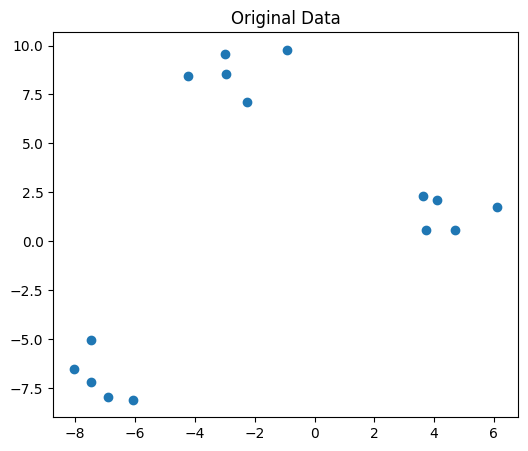

In [ ]:

X, y = make_blobs(
    n_samples=15,  # Experiment with 30, 90, 300
    centers=3,
    cluster_std=1.0,
    random_state=42
)

# Plot original data
plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1])
plt.title("Original Data")
plt.show()


In [ ]:
X

array([[-0.92998481,  9.78172086],
       [-2.97261532,  8.54855637],
       [ 6.10552761,  1.74739338],
       [-8.03062077, -6.50441157],
       [ 4.70740704,  0.5484215 ],
       [-6.05708228, -8.10095324],
       [ 3.73185476,  0.56086598],
       [-4.23411546,  8.4519986 ],
       [-7.48026588, -7.17180334],
       [-2.26723535,  7.10100588],
       [ 4.09549611,  2.08409227],
       [-7.4813338 , -5.02783141],
       [ 3.62704772,  2.28741702],
       [-6.89312442, -7.93782052],
       [-2.97867201,  9.55684617]])

# 2. SIMPLE K-MEANS FUNCTION

Prompt:
Implement following psuedocode

FUNCTION kmeans(X, k=3, max_iterations=100):
    
    STEP 1: INITIALIZATION
    - Select 'k' unique random items from dataset X.
    - Store these 'k' items in a list named 'centroids'.

    LOOP: Repeat for a maximum of 'max_iterations':

        STEP 2: CLUSTER ASSIGNMENT
        - Create an empty list named 'clusters'.
        - FOR each 'point' in X:
            - Create an empty list named 'distances'.
            - FOR each 'centroid' in 'centroids':
                - Calculate the Euclidean distance between 'point' and 'centroid'.
                - Append this distance to 'distances'.
            - Find the index of the smallest value in 'distances'.
            - Append this index to 'clusters'.

        STEP 3: CENTROID UPDATE
        - Create an empty list named 'new_centroids'.
        - FOR each cluster index 'i' from 0 to k-1:
            - Create an empty list named 'cluster_points'.
            - FOR each index 'j' from 0 to length of X - 1:
                - IF clusters[j] equals 'i':
                    - Append X[j] to 'cluster_points'.
            - Calculate the average (mean) position of all vectors in 'cluster_points'.
            - Append this average vector to 'new_centroids'.

        STEP 4: CONVERGENCE CHECK
        - IF 'centroids' matches 'new_centroids' exactly in values and position:
            - Break out of the loop.
        - Set 'centroids' equal to 'new_centroids'.

    RETURN clusters, centroids


In [ ]:

def kmeans(X, k=3, max_iterations=100):

    # Step 1: Randomly choose initial centroids
    random_indices = np.random.choice(len(X), k, replace=False)
    centroids = X[random_indices]

    # Repeat until convergence
    for iteration in range(max_iterations):

        # ====================================
        # Step 2: Assign clusters
        # ====================================

        clusters = []

        for point in X:

            # Distance from point to each centroid
            distances = []

            for centroid in centroids:
                distance = np.linalg.norm(point - centroid)
                distances.append(distance)

            # Choose nearest centroid
            cluster = np.argmin(distances)
            clusters.append(cluster)

        clusters = np.array(clusters)

        # ====================================
        # Step 3: Update centroids
        # ====================================

        new_centroids = []

        for i in range(k):

            # Points belonging to cluster i
            cluster_points = X[clusters == i]

            # Mean of cluster points
            centroid = cluster_points.mean(axis=0)

            new_centroids.append(centroid)

        new_centroids = np.array(new_centroids)

        # ====================================
        # Step 4: Stop if centroids don't move
        # ====================================

        if np.all(centroids == new_centroids):
            break

        centroids = new_centroids

    return clusters, centroids



# 3. RUN K-MEANS

In [ ]:

clusters, centroids = kmeans(X, k=3)

print("Final Centroids:\n")
print(centroids)

print("\n\nClusters:\n")
print(clusters)

Final Centroids:

[[-7.18848543 -6.94856402]
 [-2.67652459  8.68802558]
 [ 4.45346665  1.44563803]]


Clusters:

[1 1 2 0 2 0 2 1 0 1 2 0 2 0 1]


# 4. VISUALIZE CLUSTERS

Prompt:
Write a Python function using matplotlib that takes two inputs, 'X' and 'centroids', and plots them as a static 2D scatter plot.

Requirements:
1. Plot 'X' as blue circles and 'centroids' as red 'X' markers.
2. Include a title, axis labels, gridlines, and a legend.
3. Display the final plot.


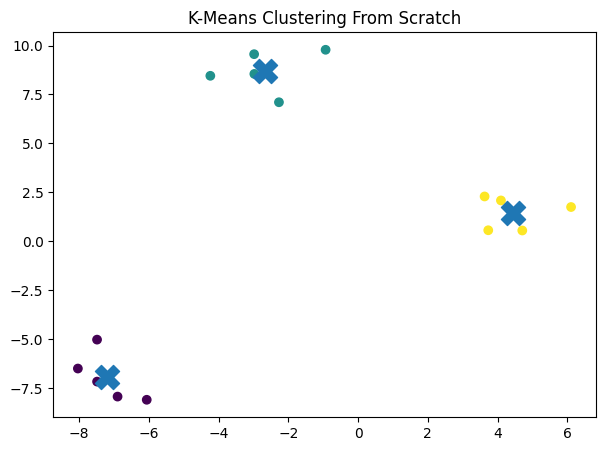

In [ ]:


plt.figure(figsize=(7, 5))

# Plot clustered points
plt.scatter(
    X[:, 0],
    X[:, 1],
    c=clusters
)

# Plot centroids
plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    s=300,
    marker='X'
)

plt.title("K-Means Clustering From Scratch")
plt.show()